#1 - Load Test Datas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

import json
import os
import random

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("All seeds set to", SEED)

All seeds set to 42


In [2]:
MODEL_COLORS = {
    "MLP"          : "#64B5F6",
    "CNN"          : "#81C784",
    "LSTM"         : "#E57373",
    "GRU"          : "#FF8A65",
    "ConvGRU"      : "#BA68C8"
}

In [3]:
ACTIVITY_NAMES = [
    "Walking", "Walking Upstairs", "Walking Downstairs",
    "Sitting", "Standing", "Laying"
]

In [4]:
N_CLASSES = 6

In [8]:
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Test samples :", X_test.shape[0])

X_test shape: (2947, 128, 9)
y_test shape: (2947,)
Test samples : 2947


## Rules of Final Evaluation

1. The test set is used ONCE and ONCE ONLY.
   Every result in this notebook is final and cannot be used
   to make further modeling decisions.

2. No model is retrained after seeing test results.
   If test accuracy is lower than validation accuracy,
   that is the honest result — it gets reported as-is.

3. Test results are compared against validation results
   to measure the generalization gap. A large gap means
   the model overfit to the validation set during development.

4. The best model for deployment is chosen based on the
   combination of test accuracy, parameter efficiency,
   and training time — not validation accuracy alone.

5. Error analysis on the test set is for understanding,
   not for further improvement. The project ends here.

#2 - Load Saved Models

In [9]:
models = {}
model_files = {
    "MLP"          : "mlp_best.keras",
    "CNN"          : "cnn_best.keras",
    "LSTM"         : "lstm_best.keras",
    "GRU"          : "gru_best.keras",
    "ConvGRU"      : "convgru_best.keras"
}

In [10]:
for model_name, path in model_files.items():
    models[model_name] = keras.models.load_model(path)
    print(f"Loaded: {model_name}")

print("\nAll models loaded successfully")

Loaded: MLP
Loaded: CNN
Loaded: LSTM
Loaded: GRU
Loaded: ConvGRU

All models loaded successfully


#3 - Run Inference on Test And Validation Sets

In [11]:
test_predictions = {}

print("Running inference on test set...")
print("=" * 50)

for model_name, model in models.items():
    probs  = model.predict(X_test, verbose=0)
    labels = np.argmax(probs, axis=1)
    acc    = np.mean(labels == y_test)

    test_predictions[model_name] = {
        "probs"    : probs,
        "labels"   : labels,
        "accuracy" : acc,
    }

    print(f"{model_name:15s} — Test Accuracy: {acc*100:.2f}%")

print("=" * 50)
print("Inference complete")

Running inference on test set...
MLP             — Test Accuracy: 91.48%
CNN             — Test Accuracy: 94.20%
LSTM            — Test Accuracy: 95.15%
GRU             — Test Accuracy: 95.76%
ConvGRU         — Test Accuracy: 95.11%
Inference complete


In [13]:
val_results = {}
result_files = {
    "MLP"          : "mlp_results.json",
    "CNN"          : "cnn_results.json",
    "LSTM"         : "lstm_results.json",
    "GRU"          : "gru_results.json",
    "ConvGRU"      : "convgru_results.json"
}

for model_name, path in result_files.items():
    with open(path) as f:
        val_results[model_name] = json.load(f)

rows = []
for model_name in models.keys():
    val_acc  = val_results[model_name]["val_accuracy"]
    test_acc = test_predictions[model_name]["accuracy"]
    gap      = val_acc - test_acc

    rows.append({
        "Model"       : model_name,
        "Val Accuracy": f"{val_acc*100:.2f}%",
        "Test Accuracy": f"{test_acc*100:.2f}%",
        "Gap"         : f"{gap*100:.2f}%",
        "Overfit?"    : "YES" if gap > 0.03 else "NO",
    })

final_df = pd.DataFrame(rows)
final_df = final_df.sort_values("Test Accuracy", ascending=False)

print("=" * 70)
print("FINAL TEST EVALUATION — VALIDATION vs TEST COMPARISON")
print("=" * 70)
print(final_df.to_string(index=False))
print("=" * 70)

FINAL TEST EVALUATION — VALIDATION vs TEST COMPARISON
  Model Val Accuracy Test Accuracy   Gap Overfit?
    GRU       99.46%        95.76% 3.70%      YES
   LSTM       99.37%        95.15% 4.22%      YES
ConvGRU       98.91%        95.11% 3.80%      YES
    CNN       99.46%        94.20% 5.26%      YES
    MLP       96.65%        91.48% 5.17%      YES


#4 - Selecting Best Model

In [14]:
best_model_name = max(
    test_predictions,
    key=lambda m: test_predictions[m]["accuracy"]
)

In [15]:
best_probs  = test_predictions[best_model_name]["probs"]
best_labels = test_predictions[best_model_name]["labels"]
best_acc    = test_predictions[best_model_name]["accuracy"]

print("=" * 50)
print("BEST MODEL SELECTED")
print("=" * 50)
print(f"Model         : {best_model_name}")
print(f"Test Accuracy : {best_acc*100:.2f}%")
print(f"Parameters    : {models[best_model_name].count_params():,}")
print("=" * 50)
print()
print("All detailed evaluation will be performed on this model.")

BEST MODEL SELECTED
Model         : GRU
Test Accuracy : 95.76%
Parameters    : 341,382

All detailed evaluation will be performed on this model.


In [19]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [20]:
print(f"Classification Report — {best_model_name} on Test Set")
print("=" * 60)
print(classification_report(
    y_test,
    best_labels,
    target_names=ACTIVITY_NAMES,
    digits=4
))

# Macro and weighted F1
macro_f1    = f1_score(y_test, best_labels, average='macro')
weighted_f1 = f1_score(y_test, best_labels, average='weighted')

print(f"Macro F1    : {macro_f1:.4f}")
print(f"Weighted F1 : {weighted_f1:.4f}")

Classification Report — GRU on Test Set
                    precision    recall  f1-score   support

           Walking     0.9920    0.9980    0.9950       496
  Walking Upstairs     0.9805    0.9618    0.9711       471
Walking Downstairs     0.9622    0.9690    0.9656       420
           Sitting     0.9242    0.8697    0.8961       491
          Standing     0.8918    0.9455    0.9179       532
            Laying     1.0000    1.0000    1.0000       537

          accuracy                         0.9576      2947
         macro avg     0.9585    0.9573    0.9576      2947
      weighted avg     0.9580    0.9576    0.9575      2947

Macro F1    : 0.9576
Weighted F1 : 0.9575


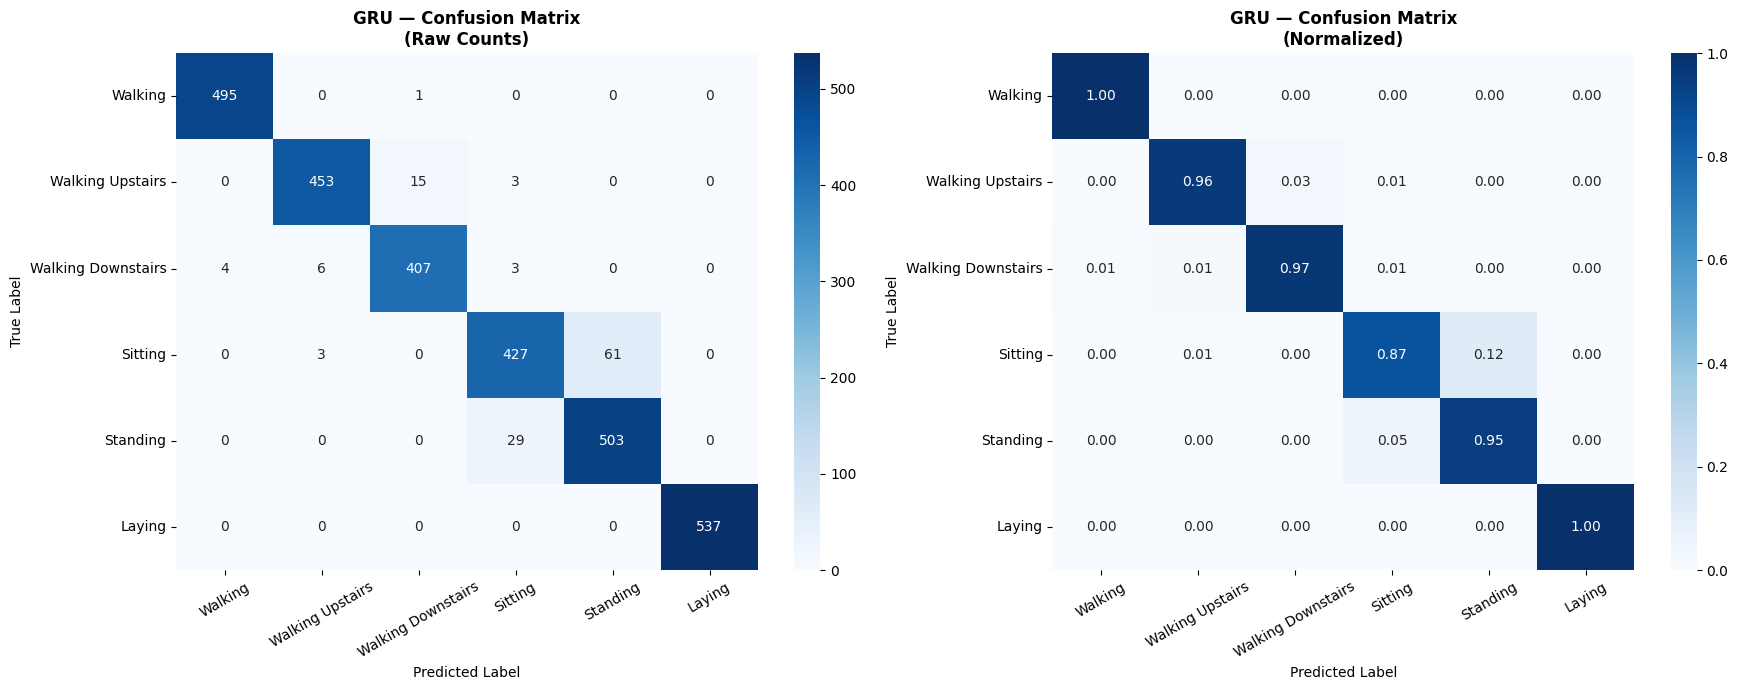

In [22]:
cm      = confusion_matrix(y_test, best_labels)
cm_norm = confusion_matrix(y_test, best_labels, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITY_NAMES,
            yticklabels=ACTIVITY_NAMES,
            ax=axes[0])
axes[0].set_title(f'{best_model_name} — Confusion Matrix\n(Raw Counts)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=30)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=ACTIVITY_NAMES,
            yticklabels=ACTIVITY_NAMES,
            ax=axes[1])
axes[1].set_title(f'{best_model_name} — Confusion Matrix\n(Normalized)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('reports/figures/final_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

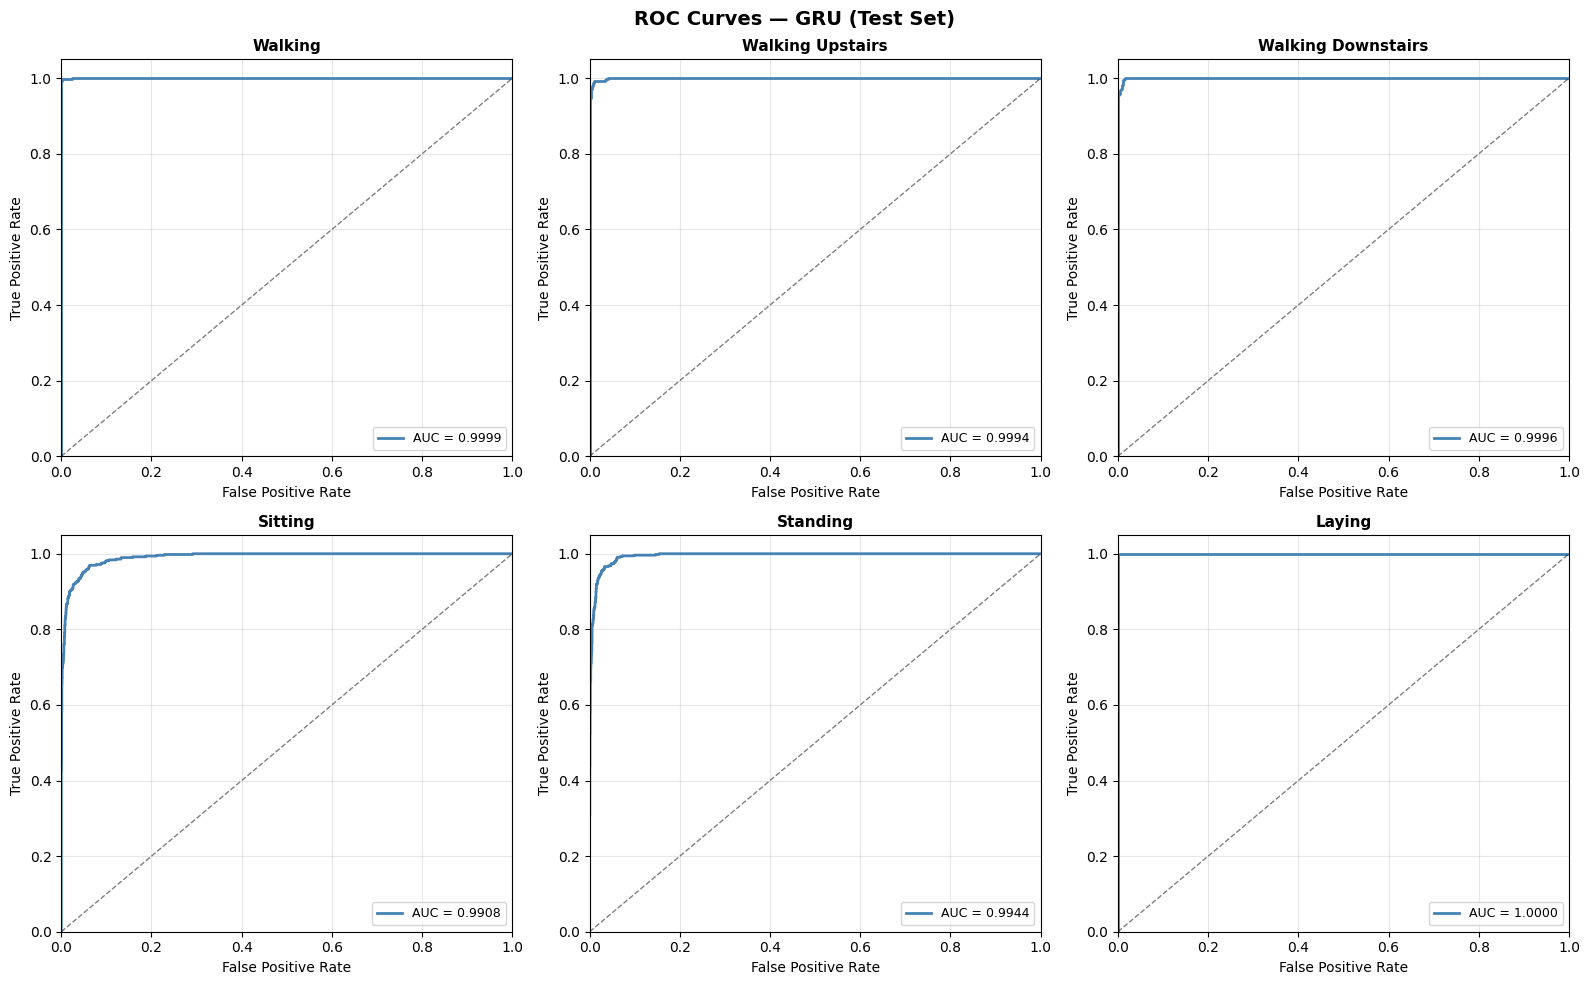


Per-class ROC-AUC scores:
  Walking                  : 0.9999
  Walking Upstairs         : 0.9994
  Walking Downstairs       : 0.9996
  Sitting                  : 0.9908
  Standing                 : 0.9944
  Laying                   : 1.0000

Macro-average AUC: 0.9974


In [25]:
y_test_bin = label_binarize(y_test, classes=range(N_CLASSES))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

roc_auc_scores = {}

for i, activity in enumerate(ACTIVITY_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_probs[:, i])
    roc_auc      = auc(fpr, tpr)
    roc_auc_scores[activity] = roc_auc

    axes[i].plot(fpr, tpr, color='steelblue',
                 linewidth=2, label=f'AUC = {roc_auc:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    axes[i].set_title(f'{activity}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])

plt.suptitle(f'ROC Curves — {best_model_name} (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-class ROC-AUC scores:")
for activity, score in roc_auc_scores.items():
    print(f"  {activity:25s}: {score:.4f}")

macro_auc = np.mean(list(roc_auc_scores.values()))
print(f"\nMacro-average AUC: {macro_auc:.4f}")

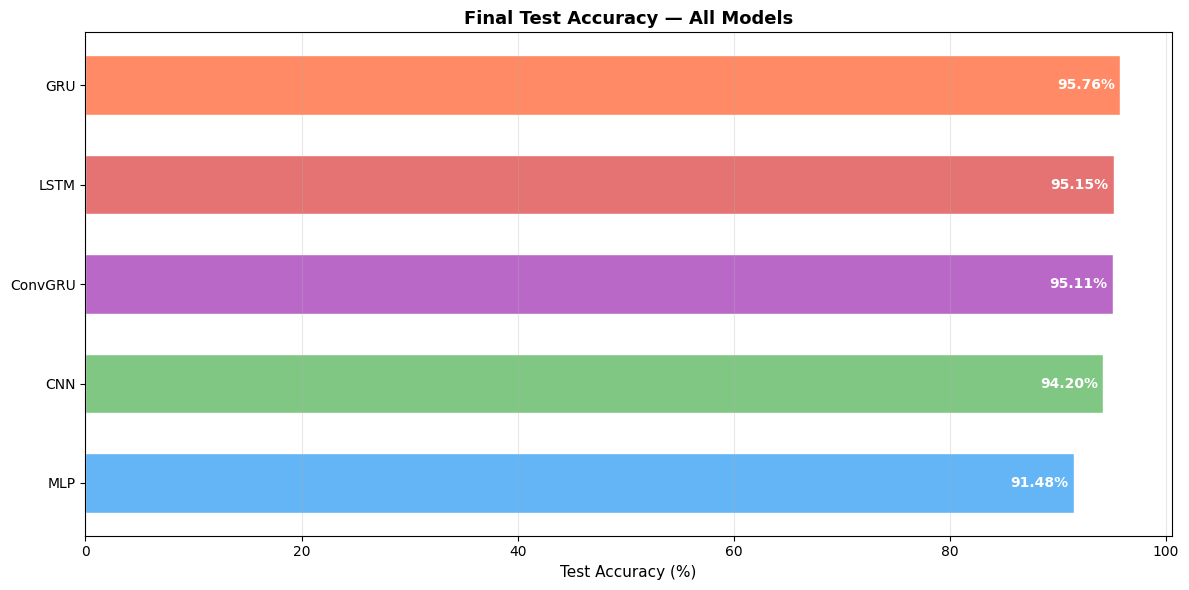

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

test_accs  = [(m, test_predictions[m]["accuracy"])
               for m in test_predictions]
test_accs  = sorted(test_accs, key=lambda x: x[1], reverse=True)

model_names = [t[0] for t in test_accs]
accuracies  = [t[1] * 100 for t in test_accs]
bar_colors  = [MODEL_COLORS[m] for m in model_names]

bars = ax.barh(model_names, accuracies,
               color=bar_colors, edgecolor='white', height=0.6)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_width() - 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{acc:.2f}%", va='center', ha='right',
            color='white', fontweight='bold', fontsize=10)

ax.set_xlabel("Test Accuracy (%)", fontsize=11)
ax.set_title("Final Test Accuracy — All Models",
             fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('reports/figures/final_test_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()

#5 - Error Analysis

In [27]:
# Step 1 — Find all misclassified samples
wrong_idx  = np.where(best_labels != y_test)[0]
correct_idx = np.where(best_labels == y_test)[0]

print(f"Total test samples    : {len(y_test)}")
print(f"Correctly classified  : {len(correct_idx)}")
print(f"Misclassified         : {len(wrong_idx)}")
print(f"Error rate            : {len(wrong_idx)/len(y_test)*100:.2f}%")
print()

# Step 2 — Find most common confusion pairs
confusion_pairs = {}
for idx in wrong_idx:
    true_label = ACTIVITY_NAMES[y_test[idx]]
    pred_label = ACTIVITY_NAMES[best_labels[idx]]
    pair = f"{true_label} → {pred_label}"
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

confusion_pairs = dict(
    sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
)

print("Most common confusion pairs:")
print("-" * 45)
for pair, count in list(confusion_pairs.items())[:5]:
    print(f"  {pair:40s}: {count} samples")

Total test samples    : 2947
Correctly classified  : 2822
Misclassified         : 125
Error rate            : 4.24%

Most common confusion pairs:
---------------------------------------------
  Sitting → Standing                      : 61 samples
  Standing → Sitting                      : 29 samples
  Walking Upstairs → Walking Downstairs   : 15 samples
  Walking Downstairs → Walking Upstairs   : 6 samples
  Walking Downstairs → Walking            : 4 samples


Plotting: True=Sitting | Predicted=Standing
Number of such errors: 61


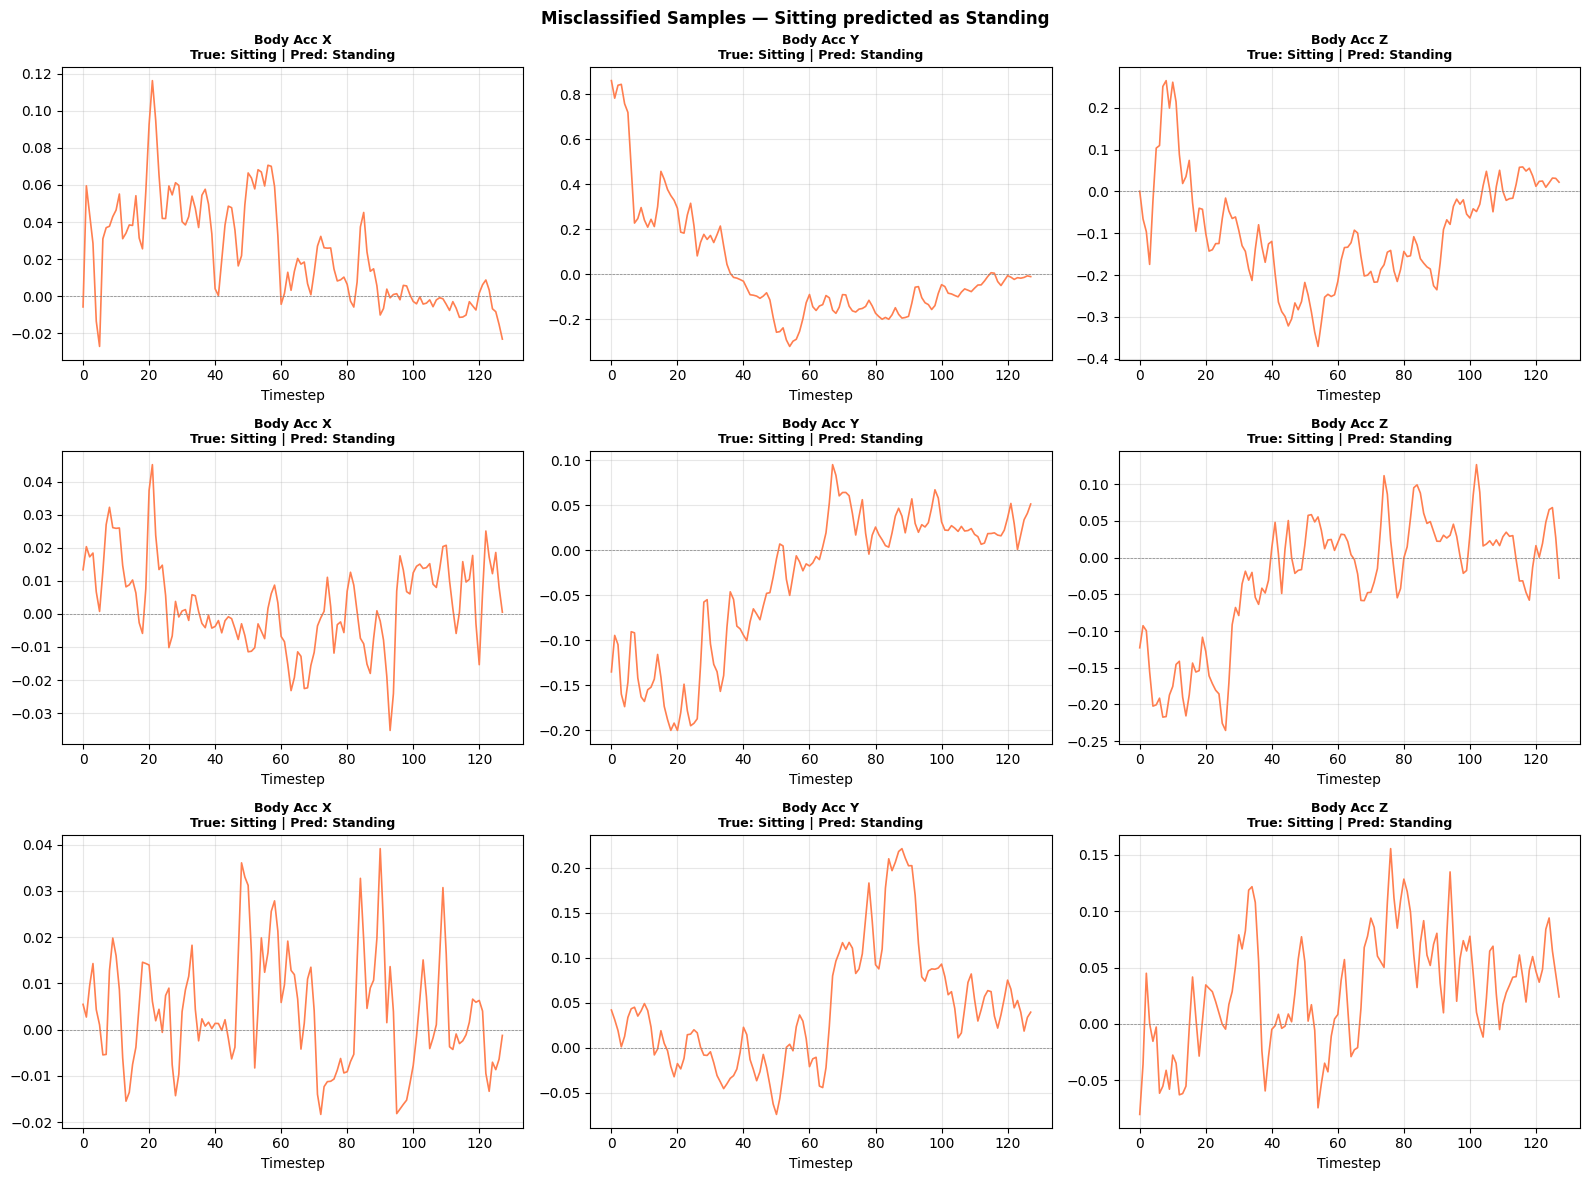

In [28]:
# Get the most confused pair
top_pair     = list(confusion_pairs.keys())[0]
true_name, pred_name = top_pair.split(" → ")
true_id  = ACTIVITY_NAMES.index(true_name)
pred_id  = ACTIVITY_NAMES.index(pred_name)

# Find samples of this confusion
confused_idx = [
    i for i in wrong_idx
    if y_test[i] == true_id and best_labels[i] == pred_id
]

print(f"Plotting: True={true_name} | Predicted={pred_name}")
print(f"Number of such errors: {len(confused_idx)}")

# Plot up to 3 misclassified samples
n_plot = min(3, len(confused_idx))
fig, axes = plt.subplots(n_plot, 3, figsize=(16, 4*n_plot))

channel_names = ['Body Acc X', 'Body Acc Y', 'Body Acc Z']

for row, idx in enumerate(confused_idx[:n_plot]):
    for col, ch in enumerate(range(3)):
        ax = axes[row][col] if n_plot > 1 else axes[col]
        ax.plot(X_test[idx, :, ch],
                color='coral', linewidth=1.2)
        ax.set_title(f"{channel_names[ch]}\n"
                     f"True: {true_name} | Pred: {pred_name}",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel("Timestep")
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle(f"Misclassified Samples — {true_name} predicted as {pred_name}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/error_analysis_signals.png',
            dpi=150, bbox_inches='tight')
plt.show()

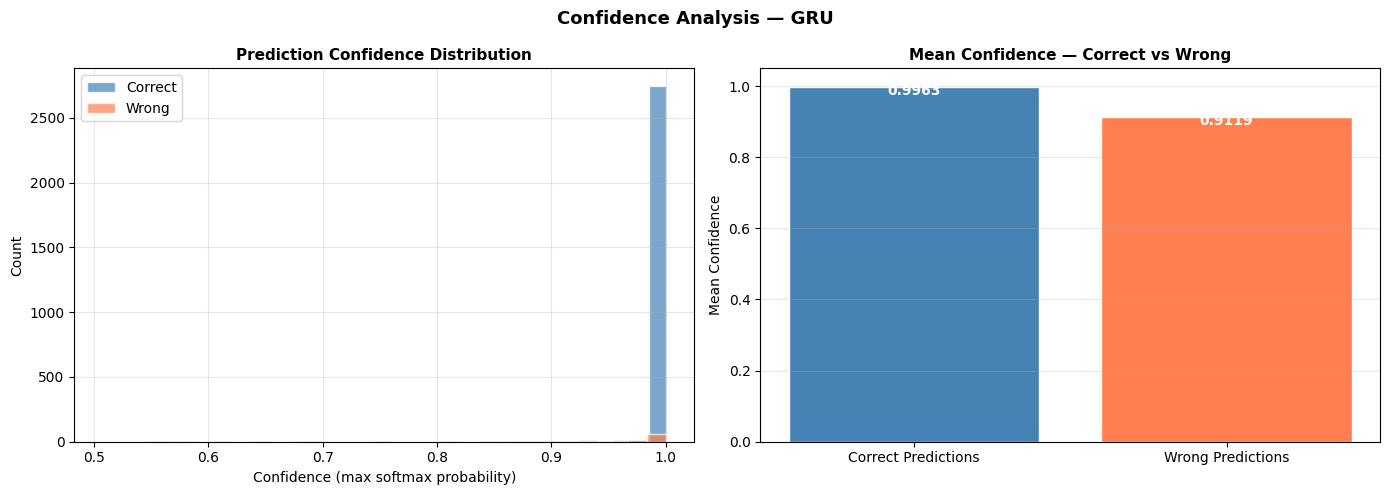

Mean confidence — Correct : 0.9963
Mean confidence — Wrong   : 0.9119
High confidence errors    : 91 samples predicted with >90% confidence but wrong


In [29]:
# Confidence on correct predictions
correct_confidence = np.max(best_probs[correct_idx], axis=1)

# Confidence on wrong predictions
wrong_confidence = np.max(best_probs[wrong_idx], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of confidence
axes[0].hist(correct_confidence, bins=30, alpha=0.7,
             color='steelblue', label='Correct', edgecolor='white')
axes[0].hist(wrong_confidence, bins=30, alpha=0.7,
             color='coral', label='Wrong', edgecolor='white')
axes[0].set_title('Prediction Confidence Distribution',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Confidence (max softmax probability)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean confidence
categories  = ['Correct Predictions', 'Wrong Predictions']
mean_conf   = [correct_confidence.mean(), wrong_confidence.mean()]
bar_colors  = ['steelblue', 'coral']

axes[1].bar(categories, mean_conf, color=bar_colors, edgecolor='white')
for i, v in enumerate(mean_conf):
    axes[1].text(i, v - 0.02, f"{v:.4f}",
                 ha='center', color='white', fontweight='bold')
axes[1].set_title('Mean Confidence — Correct vs Wrong',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Confidence')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Confidence Analysis — {best_model_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/confidence_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean confidence — Correct : {correct_confidence.mean():.4f}")
print(f"Mean confidence — Wrong   : {wrong_confidence.mean():.4f}")
print(f"High confidence errors    : "
      f"{np.sum(wrong_confidence > 0.9)} samples predicted with >90% confidence but wrong")

In [32]:
with open("results.json") as f:
    dashboard_data = json.load(f)

dashboard_data["test_results"] = {}

for model_name in models.keys():
    test_acc  = test_predictions[model_name]["accuracy"]
    test_preds = test_predictions[model_name]["labels"]
    test_f1   = f1_score(y_test, test_preds, average='macro')
    val_acc   = val_results[model_name]["val_accuracy"]
    gap       = val_acc - test_acc

    dashboard_data["test_results"][model_name] = {
        "test_accuracy"  : round(float(test_acc), 4),
        "test_f1_macro"  : round(float(test_f1), 4),
        "val_accuracy"   : round(float(val_acc), 4),
        "generalization_gap" : round(float(gap), 4),
    }

dashboard_data["best_model"] = {
    "name"           : best_model_name,
    "test_accuracy"  : round(float(best_acc), 4),
    "test_f1_macro"  : round(float(macro_f1), 4),
    "macro_auc"      : round(float(macro_auc), 4),
    "roc_auc_scores" : {k: round(v, 4)
                        for k, v in roc_auc_scores.items()},
    "error_analysis" : {
        "total_errors"       : int(len(wrong_idx)),
        "error_rate"         : round(len(wrong_idx)/len(y_test), 4),
        "top_confusion_pairs": [
            {"pair": k, "count": v}
            for k, v in list(confusion_pairs.items())[:3]
        ],
        "mean_confidence_correct" : round(float(correct_confidence.mean()), 4),
        "mean_confidence_wrong"   : round(float(wrong_confidence.mean()), 4),
        "high_confidence_errors"  : int(np.sum(wrong_confidence > 0.9)),
    }
}

In [33]:

with open("results.json", "w") as f:
    json.dump(dashboard_data, f, indent=2)

print("dashboard/src/data/results.json updated with test results")
print()
print("=" * 55)
print("FINAL EVALUATION COMPLETE")
print("=" * 55)
print(f"Best Model       : {best_model_name}")
print(f"Test Accuracy    : {best_acc*100:.2f}%")
print(f"Test Macro F1    : {macro_f1*100:.2f}%")
print(f"Macro AUC        : {macro_auc:.4f}")
print(f"Total Errors     : {len(wrong_idx)}")
print(f"High Conf Errors : {np.sum(wrong_confidence > 0.9)}")
print("=" * 55)

dashboard/src/data/results.json updated with test results

FINAL EVALUATION COMPLETE
Best Model       : GRU
Test Accuracy    : 95.76%
Test Macro F1    : 95.76%
Macro AUC        : 0.9974
Total Errors     : 125
High Conf Errors : 91


## Error Analysis — Final Findings

### Error Distribution
```
Total test samples   : 2947
Correctly classified : 2822  (95.76%)
Misclassified        : 125   (4.24%)
```

### Confusion Breakdown
| Confusion Pair                      | Count | % of Errors |
|-------------------------------------|-------|-------------|
| Sitting → Standing                  | 61    | 48.8%       |
| Standing → Sitting                  | 29    | 23.2%       |
| Walking Upstairs → Downstairs       | 15    | 12.0%       |
| Walking Downstairs → Upstairs       | 6     | 4.8%        |
| Walking Downstairs → Walking        | 4     | 3.2%        |

Sitting ↔ Standing accounts for 72% of all errors.
Walking variants account for 20% of all errors.

### Why Sitting ↔ Standing is hardest
Both activities produce nearly identical sensor signatures —
nearly vertical phone orientation, minimal movement, low variance.
The distinction requires detecting microscopic postural differences
that a 2.56-second raw signal window cannot reliably carry.

The confusion is asymmetric (61 vs 29) — the model is biased
toward predicting Standing, the slightly more dynamic activity.

### ROC-AUC by Class
| Activity           | AUC    | Interpretation        |
|--------------------|--------|-----------------------|
| Laying             | 1.0000 | Perfect separation    |
| Walking            | 0.9999 | Near perfect          |
| Walking Downstairs | 0.9996 | Near perfect          |
| Walking Upstairs   | 0.9994 | Near perfect          |
| Standing           | 0.9944 | Slight difficulty     |
| Sitting            | 0.9908 | Most confused class   |

AUC ranking mirrors confusion matrix exactly.
The entire difficulty of this dataset is concentrated
in distinguishing Sitting from Standing.

### Implication for deployment
A production HAR system should apply additional post-processing
for the Sitting/Standing boundary — for example:
- Using a longer window (5+ seconds) for static activity detection
- Adding barometric pressure sensor data to detect elevation
- Using a secondary lightweight classifier specifically for
  the Sitting vs Standing decision

## Revised Finding — Validation vs Test Rankings Reversed

CNN ranked first on validation (99.46%) but fourth on test (94.20%).
GRU tied CNN on validation but outperformed it by 1.56% on test.

CNN's convolutional filters learned local signal patterns specific
to the 21 training subjects. These patterns did not generalise
as well to the 9 unseen test subjects.

GRU's sequential modeling learned temporal transitions and rhythms
that are more consistent across different people performing
the same activity — making it more subject-independent.

This finding highlights a critical lesson:
Validation accuracy on seen subjects is an optimistic estimate.
True model quality is only revealed on completely unseen subjects.
Never select a deployment model based on validation accuracy alone.